# Notebook 1 — Tokenizer Comparison
**Adapted for Jupyter Notebook / Kubeflow**

Compares tokenizers across **tiktoken**, **HuggingFace**, and **SentencePiece** families.
No Colab-specific code — runs as-is on Jupyter, Kubeflow, or any local Python environment.

**Learning objectives:**
- Explain why tokenization affects LLM cost, quality, and context window usage
- Compare tokenizer behaviour across English, code, emoji, Hindi, and mixed text
- Interpret token pieces, IDs, round-trip decoding, and token counts

In [1]:
# Install required packages (run once)
# On Kubeflow Terminal, run without the ! prefix
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "tiktoken", "transformers", "sentencepiece",
                "pandas", "numpy", "matplotlib", "seaborn", "ipywidgets", "-q"])

CompletedProcess(args=['/home/jovyan/llmall/venv/bin/python', '-m', 'pip', 'install', 'tiktoken', 'transformers', 'sentencepiece', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'ipywidgets', '-q'], returncode=0)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import time, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken
from transformers import AutoTokenizer

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")
print("✅ Imports complete")

✅ Imports complete


## Why Tokenizers Matter

A tokenizer is the bridge between raw text and model inputs.
Models do not read characters or words — they read **token IDs** (integers).

Tokenization affects:
- **Context window usage** — more tokens per sentence = less text fits in one request
- **API cost** — cloud LLM APIs charge per token
- **Language quality** — a tokenizer trained on English fragments Hindi or Arabic into meaningless bytes
- **Code efficiency** — newer tokenizers represent Python keywords as single tokens

> **Same text, different tokenizer = different computation budget.**

## Sample Texts — Intentionally Diverse

In [3]:
examples = [
    "Hello world",
    "Café 🚀",
    "def add(x, y): return x + y",
    "नमस्ते world",
    "The cat sat on the mat.",
    "Email me at demo@example.com by 10:30 AM.",
    "GPU-memory-efficient attention is important for long-context models.",
    "🙂🙂🙂 emoji-rich text with symbols ©™✓",
    "Multiple     spaces and new lines\ttoo.",
    "Translate this sentence from English to Hindi: The weather is pleasant today."
]

print(f"Loaded {len(examples)} example strings")
for i, ex in enumerate(examples):
    print(f"  [{i}] {ex[:60]}")

Loaded 10 example strings
  [0] Hello world
  [1] Café 🚀
  [2] def add(x, y): return x + y
  [3] नमस्ते world
  [4] The cat sat on the mat.
  [5] Email me at demo@example.com by 10:30 AM.
  [6] GPU-memory-efficient attention is important for long-context
  [7] 🙂🙂🙂 emoji-rich text with symbols ©™✓
  [8] Multiple     spaces and new lines	too.
  [9] Translate this sentence from English to Hindi: The weather i


## Load Tokenizers

Six tokenizers from three families:

| Name | Library | Algorithm | Vocab size |
|---|---|---|---|
| `tiktoken:r50k_base` | tiktoken | BPE | 50,000 |
| `tiktoken:cl100k_base` | tiktoken | BPE | 100,277 — GPT-3.5 / GPT-4 |
| `tiktoken:o200k_base` | tiktoken | BPE | 200,019 — GPT-4o |
| `hf:gpt2` | HuggingFace | BPE | 50,257 — marks spaces with `Ġ` |
| `hf:llama` | HuggingFace | SentencePiece | 32,000 — marks spaces with `▁` |
| `hf:t5-small` | HuggingFace | WordPiece | 30,522 — marks sub-words with `##` |

In [4]:
# tiktoken encodings — fast, OpenAI-style BPE
encodings = {
    "tiktoken:r50k_base"  : tiktoken.get_encoding("r50k_base"),
    "tiktoken:cl100k_base": tiktoken.get_encoding("cl100k_base"),
    "tiktoken:o200k_base" : tiktoken.get_encoding("o200k_base"),
}

# HuggingFace tokenizers — full preprocessing pipelines
hf_tokenizers = {
    "hf:gpt2" : AutoTokenizer.from_pretrained("gpt2"),
    "hf:llama": AutoTokenizer.from_pretrained("NousResearch/Llama-2-7b-chat-hf"),
    "hf:t5-small": AutoTokenizer.from_pretrained("t5-small"),
}

print("✅ Tokenizers loaded:", list(encodings.keys()) + list(hf_tokenizers.keys()))

tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizers loaded: ['tiktoken:r50k_base', 'tiktoken:cl100k_base', 'tiktoken:o200k_base', 'hf:gpt2', 'hf:llama', 'hf:t5-small']


## Helper Functions

In [5]:
def tiktoken_view(enc, text):
    """Tokenize text with tiktoken; return pieces, ids, decoded, count, roundtrip."""
    ids          = enc.encode(text)
    pieces       = [enc.decode([i]) for i in ids]
    decoded      = enc.decode(ids)
    token_count  = len(ids)
    roundtrip    = (decoded == text)
    return {"pieces": pieces, "ids": ids, "decoded": decoded,
            "token_count": token_count, "roundtrip_match": roundtrip}


def hf_view(tok, text):
    """Tokenize text with a HuggingFace tokenizer; same output format as tiktoken_view."""
    batch        = tok(text, add_special_tokens=False)
    ids          = batch["input_ids"]
    pieces       = tok.convert_ids_to_tokens(ids)
    decoded      = tok.decode(ids, skip_special_tokens=True)
    token_count  = len(ids)
    roundtrip    = (decoded == text)
    return {"pieces": pieces, "ids": ids, "decoded": decoded,
            "token_count": token_count, "roundtrip_match": roundtrip}


def inspect_text(text):
    """Run all tokenizers on text; return unified DataFrame."""
    rows = []
    for name, enc in encodings.items():
        rows.append({"tool": name, "text": text, **tiktoken_view(enc, text)})
    for name, tok in hf_tokenizers.items():
        rows.append({"tool": name, "text": text, **hf_view(tok, text)})
    return pd.DataFrame(rows)

print("✅ Helper functions defined")

✅ Helper functions defined


## Single-Text Walkthrough — `Café 🚀`

In [6]:
single_text = "Café 🚀"
inspect_text(single_text)[["tool", "token_count", "pieces", "ids", "roundtrip_match"]]

,tool,token_count,pieces,ids,roundtrip_match
0,tiktoken:r50k_base,6,"[C, af, é, �, �, �]","[34, 1878, 2634, 12520, 248, 222]",True
1,tiktoken:cl100k_base,6,"[C, af, é, �, �, �]","[34, 2642, 978, 11410, 248, 222]",True
2,tiktoken:o200k_base,4,"[C, afé, �, �]","[34, 103112, 169883, 222]",True
3,hf:gpt2,6,"[C, af, Ã©, ĠðŁ, ļ, Ģ]","[34, 1878, 2634, 12520, 248, 222]",True
4,hf:llama,7,"[▁C, afé, ▁, <0xF0>, <0x9F>, <0x9A>, <0x80>]","[315, 28059, 29871, 243, 162, 157, 131]",True
5,hf:t5-small,3,"[▁Café, ▁, <unk>]","[18131, 3, 2]",False


## All Examples — Token Count Comparison

In [7]:
all_rows = [inspect_text(text) for text in examples]
results_df = pd.concat(all_rows, ignore_index=True)
results_df[["tool", "text", "token_count", "roundtrip_match"]]

,tool,text,token_count,roundtrip_match
0,tiktoken:r50k_base,Hello world,2,True
1,tiktoken:cl100k_base,Hello world,2,True
2,tiktoken:o200k_base,Hello world,2,True
3,hf:gpt2,Hello world,2,True
4,hf:llama,Hello world,2,True
5,hf:t5-small,Hello world,2,True
6,tiktoken:r50k_base,Café 🚀,6,True
7,tiktoken:cl100k_base,Café 🚀,6,True
8,tiktoken:o200k_base,Café 🚀,4,True
9,hf:gpt2,Café 🚀,6,True


## Error Analysis — How Tricky Text is Split

In [8]:
interesting = ["Café 🚀", "नमस्ते world", "🙂🙂🙂 emoji-rich text with symbols ©™✓",
               "def add(x, y): return x + y"]
results_df[results_df["text"].isin(interesting)][["tool", "text", "token_count", "pieces"]]

,tool,text,token_count,pieces
6,tiktoken:r50k_base,Café 🚀,6,"[C, af, é, �, �, �]"
7,tiktoken:cl100k_base,Café 🚀,6,"[C, af, é, �, �, �]"
8,tiktoken:o200k_base,Café 🚀,4,"[C, afé, �, �]"
9,hf:gpt2,Café 🚀,6,"[C, af, Ã©, ĠðŁ, ļ, Ģ]"
10,hf:llama,Café 🚀,7,"[▁C, afé, ▁, <0xF0>, <0x9F>, <0x9A>, <0x80>]"
11,hf:t5-small,Café 🚀,3,"[▁Café, ▁, <unk>]"
12,tiktoken:r50k_base,"def add(x, y): return x + y",11,"[def, add, (, x, ,, y, ):, return, x, +, y]"
13,tiktoken:cl100k_base,"def add(x, y): return x + y",10,"[def, add, (x, ,, y, ):, return, x, +, y]"
14,tiktoken:o200k_base,"def add(x, y): return x + y",10,"[def, add, (x, ,, y, ):, return, x, +, y]"
15,hf:gpt2,"def add(x, y): return x + y",11,"[def, Ġadd, (, x, ,, Ġy, ):, Ġreturn, Ġx, Ġ+, Ġy]"


## Average Token Count — Efficiency Ranking

In [9]:
avg_df = (
    results_df
    .groupby("tool", as_index=False)["token_count"]
    .mean()
    .sort_values("token_count")
    .rename(columns={"token_count": "avg_token_count"})
)
avg_df

,tool,avg_token_count
4,tiktoken:o200k_base,8.6
3,tiktoken:cl100k_base,9.4
2,hf:t5-small,10.1
0,hf:gpt2,11.0
5,tiktoken:r50k_base,11.0
1,hf:llama,11.7


## Bar Chart — Average Tokens per Tokenizer

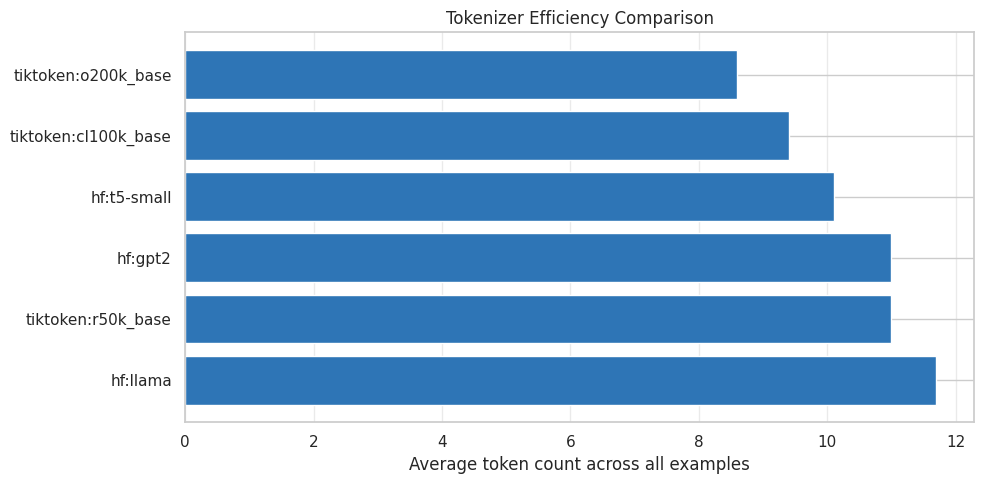

Chart saved to ./tokenizer_comparison.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(avg_df["tool"], avg_df["avg_token_count"], color="#2E75B6")
ax.set_xlabel("Average token count across all examples")
ax.set_title("Tokenizer Efficiency Comparison")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig("./tokenizer_comparison.png", dpi=150)
plt.show()
print("Chart saved to ./tokenizer_comparison.png")

## Vocabulary and Metadata

In [11]:
def safe_vocab_size(tok):
    try:    return tok.vocab_size
    except: return len(tok.get_vocab()) if hasattr(tok, "get_vocab") else None

meta_rows = []
for name, tok in hf_tokenizers.items():
    meta_rows.append({
        "tool": name, "class": tok.__class__.__name__,
        "vocab_size": safe_vocab_size(tok),
        "model_max_length": getattr(tok, "model_max_length", None),
        "special_tokens": tok.all_special_tokens,
    })
for name, enc in encodings.items():
    meta_rows.append({
        "tool": name, "class": enc.__class__.__name__,
        "vocab_size": getattr(enc, "n_vocab", None),
        "model_max_length": None,
        "special_tokens": "encoding-defined",
    })
pd.DataFrame(meta_rows)

,tool,class,vocab_size,model_max_length,special_tokens
0,hf:gpt2,GPT2TokenizerFast,50257,1024,[<|endoftext|>]
1,hf:llama,LlamaTokenizerFast,32000,1000000000000000019884624838656,"[<s>, </s>, <unk>]"
2,hf:t5-small,T5TokenizerFast,32100,512,"[</s>, <unk>, <pad>, <extra_id_0>, <extra_id_1>, <extra_id_2>, <extra_id_3>, <extra_id_4>, <extra_id_5>, <extra_id_6>, <extra_id_7>, <extra_id_8>, <extra_id_9>, <extra_id_10>, <extra_id_11>, <extr..."
3,tiktoken:r50k_base,Encoding,50257,None,encoding-defined
4,tiktoken:cl100k_base,Encoding,100277,None,encoding-defined
5,tiktoken:o200k_base,Encoding,200019,None,encoding-defined


## Reusable Function — Try Any Text

In [12]:
def compare_any_text(text, show_pieces=True):
    """Run all tokenizers on any string. Paste your own text here."""
    df = inspect_text(text)
    cols = ["tool", "token_count", "roundtrip_match"]
    if show_pieces:
        cols.append("pieces")
    return df[cols]

# ── Try your own text below ──────────────────────────────────────
compare_any_text("Large language models require careful token budgeting for long-context prompting.")

,tool,token_count,roundtrip_match,pieces
0,tiktoken:r50k_base,14,True,"[Large, language, models, require, careful, token, budget, ing, for, long, -, context, prompting, .]"
1,tiktoken:cl100k_base,13,True,"[Large, language, models, require, careful, token, budget, ing, for, long, -context, prompting, .]"
2,tiktoken:o200k_base,12,True,"[Large, language, models, require, careful, token, budgeting, for, long, -context, prompting, .]"
3,hf:gpt2,14,True,"[Large, Ġlanguage, Ġmodels, Ġrequire, Ġcareful, Ġtoken, Ġbudget, ing, Ġfor, Ġlong, -, context, Ġprompting, .]"
4,hf:llama,16,True,"[▁Lar, ge, ▁language, ▁models, ▁require, ▁careful, ▁token, ▁budget, ing, ▁for, ▁long, -, context, ▁prompt, ing, .]"
5,hf:t5-small,16,True,"[▁Large, ▁language, ▁models, ▁require, ▁careful, ▁token, ▁budget, ing, ▁for, ▁long, -, con, text, ▁prompt, ing, .]"


## Key Takeaways

| Concept | Summary |
|---|---|
| Tokenization is model-specific | The same text produces different IDs across tokenizers |
| Newer tokenizers are more efficient | Larger vocab absorbs common patterns as single tokens |
| Multilingual text challenges older tokenizers | GPT-2 fragments Hindi into byte-level pieces |
| `roundtrip_match=False` is not a bug | Some tokenizers apply Unicode normalization during decode |
| Token count = compute cost | Fewer tokens → less context window used → lower API cost |